# 02 - Logistic Regression (Person 1)

**Task:** predict whether a mortgage is prepaid within 24 months (`1`) or not (`0`).
Uses the data saved by `01_data_preprocessing.ipynb` (same train/test split as every other model).

**How Logistic Regression works:** it computes a weighted sum of the features, `z = w.x + b`, and passes it through the sigmoid
`P(y=1|x) = 1 / (1 + e^-z)`. Weights are learned by minimising the log-loss. The decision boundary is **linear**.
We use the default **L2 regularisation** (penalises large weights) and choose its strength `C` by cross-validation
(smaller `C` = stronger regularisation).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

PROC, METRICS, CM, PLOTS = "../data/processed", "../results/metrics", "../results/confusion_matrices", "../results/plots"
TAG = "logistic_regression"      # file-name prefix for this model's results
SEED = 42

## 1. Load the processed data

In [2]:
X_train = pd.read_csv(f"{PROC}/X_train.csv")
X_test = pd.read_csv(f"{PROC}/X_test.csv")
y_train = pd.read_csv(f"{PROC}/y_train.csv")["target"]
y_test = pd.read_csv(f"{PROC}/y_test.csv")["target"]
print("Train:", X_train.shape, " Test:", X_test.shape)

# A model that always predicts the majority class - our reference point
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print("Majority-class baseline accuracy on test: %.4f" % baseline_acc)

Train: (39288, 20)  Test: (9823, 20)
Majority-class baseline accuracy on test: 0.5243


## 2. Choose the regularisation strength `C`
Only one small search: 5-fold cross-validation **on the training set** over four values of `C`, scored by ROC-AUC.
The test set is not used here.

In [3]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),          # default penalty is L2, solver is lbfgs
    param_grid={"C": [0.01, 0.1, 1, 10]},
    cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

print(pd.DataFrame(grid.cv_results_)[["param_C", "mean_test_score"]].round(4))
print("Best C:", grid.best_params_["C"])
model = grid.best_estimator_      # refitted on the full training set with the best C

   param_C  mean_test_score
0     0.01           0.6928
1     0.10           0.6932
2     1.00           0.6933
3    10.00           0.6933
Best C: 1


## 3. Predict and evaluate

In [4]:
def get_metrics(y_true, y_pred, y_prob):
    """Same metric set for every model. Precision/recall/F1 are for class 1 (Prepayment)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred)),
        "recall": float(recall_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# Predicted probability of class 1, and the class label using the usual 0.5 threshold
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)
train_prob = model.predict_proba(X_train)[:, 1]
train_pred = (train_prob >= 0.5).astype(int)

train_metrics = get_metrics(y_train, train_pred, train_prob)
test_metrics = get_metrics(y_test, test_pred, test_prob)

print(pd.DataFrame({"train": train_metrics, "test": test_metrics}).round(4))

                train       test
accuracy       0.6445     0.6474
precision      0.6581     0.6621
recall         0.6700     0.6685
f1             0.6640     0.6653
roc_auc        0.6941     0.7004
tn         11520.0000  2916.0000
fp          7169.0000  1757.0000
fn          6798.0000  1707.0000
tp         13801.0000  3443.0000


Train and test numbers close together = the model is not overfitting. Compare the test accuracy with the majority-class baseline above.

## 4. Confusion matrix and ROC curve

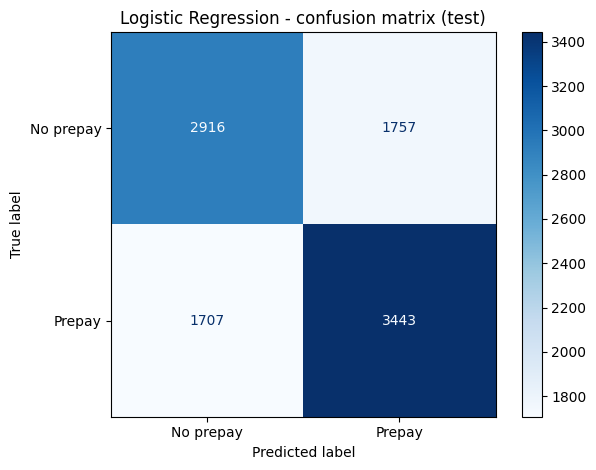

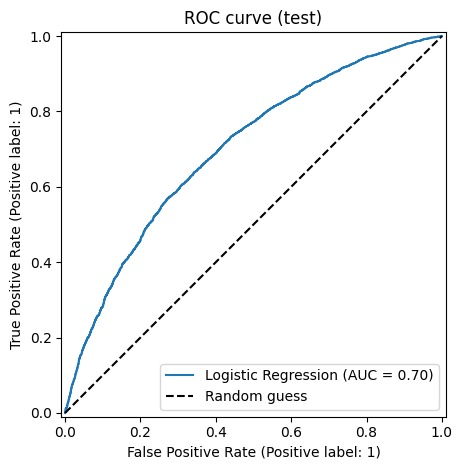

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["No prepay", "Prepay"], cmap="Blues")
plt.title("Logistic Regression - confusion matrix (test)")
plt.tight_layout(); plt.savefig(f"{PLOTS}/{TAG}_confusion_matrix.png", dpi=150); plt.show()

RocCurveDisplay.from_predictions(y_test, test_prob, name="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.legend(); plt.title("ROC curve (test)")
plt.tight_layout(); plt.savefig(f"{PLOTS}/{TAG}_roc_curve.png", dpi=150); plt.show()

## 5. Which features matter?
Features were standardised in preprocessing, so coefficient sizes are comparable.
Positive coefficient = higher chance of prepayment; negative = lower chance.

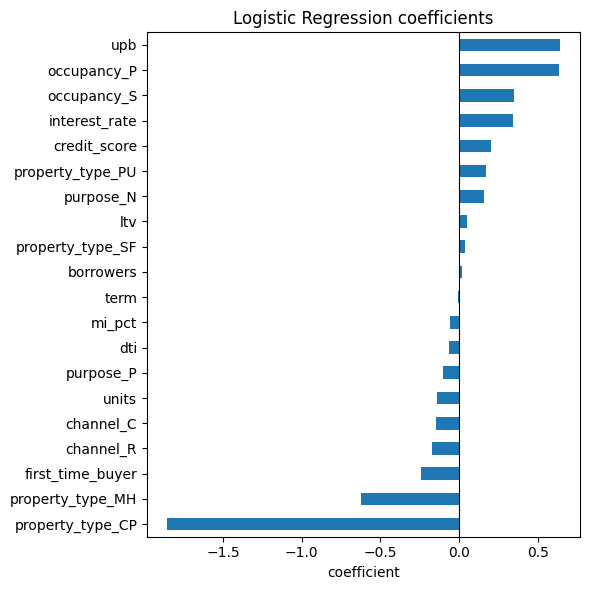

property_type_CP   -1.858
upb                 0.643
occupancy_P         0.633
property_type_MH   -0.626
occupancy_S         0.349
interest_rate       0.340
first_time_buyer   -0.239
credit_score        0.201
dtype: float64


In [6]:
coefs = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
plt.figure(figsize=(6, 6))
coefs.plot.barh()
plt.axvline(0, color="k", lw=0.8)
plt.title("Logistic Regression coefficients"); plt.xlabel("coefficient")
plt.tight_layout(); plt.savefig(f"{PLOTS}/{TAG}_coefficients.png", dpi=150); plt.show()
print(coefs.round(3).sort_values(key=abs, ascending=False).head(8))

## 6. Save results (shared format so SVM / GDA can be added later)

In [7]:
result = {
    "model": "Logistic Regression",
    "task": "Prepayment within 24 months (1) vs no prepayment (0)",
    "n_train": int(len(X_train)), "n_test": int(len(X_test)), "n_features": int(X_train.shape[1]),
    "split_seed": SEED,
    "hyperparameters": {"penalty": "l2", "C": grid.best_params_["C"], "solver": "lbfgs", "max_iter": 1000,
                        "threshold": 0.5, "tuning": "5-fold CV on train over C in [0.01, 0.1, 1, 10], scoring roc_auc"},
    "baseline_majority_accuracy_test": float(baseline_acc),
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
}
with open(f"{METRICS}/{TAG}_metrics.json", "w") as f:
    json.dump(result, f, indent=2)

pd.DataFrame({"y_true": y_test, "y_pred": test_pred, "y_prob": test_prob.round(6)}).to_csv(
    f"{METRICS}/{TAG}_test_predictions.csv", index=False)

cm = confusion_matrix(y_test, test_pred)
pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]).to_csv(
    f"{CM}/{TAG}_confusion_matrix.csv")
print("Saved results for", TAG)

Saved results for logistic_regression


## 7. Interpretation
(Numbers below are from our saved run, `results/metrics/logistic_regression_metrics.json`.)

- **Better than guessing, but modest.** Test accuracy is about 64.7 % versus 52.4 % for always predicting "No prepayment"; ROC-AUC is about 0.70 (0.5 = random). Precision, recall and F1 are all around 0.66-0.67, so the model makes similar numbers of false positives and false negatives.
- **No overfitting.** Train and test metrics are almost identical (accuracy 64.5 % vs 64.7 %), as expected for a simple linear model with 20 features.
- **Regularisation barely mattered.** Cross-validated AUC was 0.693 for every `C` from 0.01 to 10, so the choice of `C` is not important here.
- **Why the ceiling is low.** Whether someone refinances in the next two years depends heavily on things that are not in the data (future mortgage rates, borrower behaviour). Origination information alone only explains part of it. The reference paper's ~99 % accuracy came from leakage (`current_UPB`) and is not comparable.
- **Coefficients.** Larger loan amount, owner-occupied (`occupancy_P`) and second-home (`occupancy_S`) loans, and higher interest rate all push the prediction towards prepayment; first-time buyers push it down. One-hot coefficients are relative to the dropped category (e.g. occupancy is relative to *investor* loans). `property_type_CP` (co-ops) has a large coefficient but there are very few such loans, so it should not be over-interpreted.
- **Limitation:** Logistic Regression is linear in the features. Earlier we saw the prepayment rate rises and then falls with interest rate, which a single linear coefficient cannot represent.

No model is declared best here; that comparison waits until SVM and GDA are done.